In [1]:
import random
import numpy
import matplotlib.pyplot as plt
import joblib

from outlier_cleaner import outlierCleaner

In [2]:
### load up some practice data with outliers in it
ages = joblib.load( open(r"D:\machine_learning\ud120-projects\outliers\practice_outliers_ages.pkl", "rb") )
net_worths = joblib.load( open(r"D:\machine_learning\ud120-projects\outliers\practice_outliers_net_worths.pkl", "rb") )

In [3]:
### ages and net_worths need to be reshaped into 2D numpy arrays
### second argument of reshape command is a tuple of integers: (n_rows, n_columns)
### by convention, n_rows is the number of data points
### and n_columns is the number of features
ages = numpy.reshape( numpy.array(ages), (len(ages), 1))
net_worths = numpy.reshape( numpy.array(net_worths), (len(net_worths), 1))
from sklearn.model_selection import train_test_split
ages_train, ages_test, net_worths_train, net_worths_test = train_test_split(ages, net_worths, test_size=0.1, random_state=42)

In [4]:
### fill in a regression here!  Name the regression object reg so that
### the plotting code below works, and you can see what your regression looks like

from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(ages_train, net_worths_train)

LinearRegression()

Sebastian described to us an algorithm for improving a regression, which you will implement in this project. You will work through it in the next few quizzes. To summarize, what you'll do is fit the regression on all training points discard the 10% of points that have the largest errors between the actual y values, and the regression-predicted y values refit on the remaining points.

Start by running the starter code (outliers/outlier_removal_regression.py) and visualizing the points. A few outliers should clearly pop out. Deploy a linear regression, where net worth is the target and the feature being used to predict it is a person’s age (remember to train on the training data!).

The “correct” slope for the main body of data points is 6.25 (we know this because we used this value to generate the data); 

**what slope does your regression have?**

In [5]:
print("slope: ", reg.coef_)

slope:  [[5.07793064]]


**What is the score you get when using your regression to make predictions with the test data?**

In [6]:
print("score: ", reg.score(ages_test, net_worths_test))

score:  0.8782624703664673


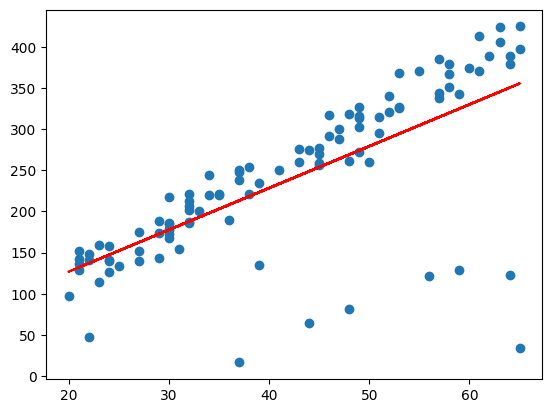

In [7]:
try:
    plt.plot(ages, reg.predict(ages), color="red")
except NameError:
    pass
plt.scatter(ages, net_worths)
plt.show()

In outliers/outlier_cleaner.py, you will find the skeleton for a function called outlierCleaner() that you will fill in with a cleaning algorithm. It takes three arguments: predictions is a list of predicted targets that come from your regression, ages is the list of ages in the training set, and net_worths is the actual value of the net worths in the training set. There should be 90 elements in each of these lists (because the training set has 90 points in it). Your job is to return a list called cleaned_data that has only 81 elements in it, which are the 81 training points where the predictions and the actual values (net_worths) have the smallest errors (90 * 0.9 = 81). The format of cleaned_data should be a list of tuples, where each tuple has the form (age, net_worth, error).

Once this cleaning function is working, you should see the regression result changes. 

**What is the new slope?**

 Is it closer to the “correct” result of 6.25?

In [8]:
'''
I will be using pandas library to handle data because it provides easy-to-use data structures and data analysis tools,
and I'm familiar with it.
'''
import pandas as pd

In [9]:
### identify and remove the most outlier-y points
cleaned_data = []
try:
    predictions = reg.predict(ages_train)
    cleaned_data = outlierCleaner(predictions, ages_train, net_worths_train)
except NameError:
    print("your regression object doesn't exist, or isn't named reg")
    print("can't make predictions to use in identifying outliers")

In [10]:
# turn cleaned_data into pandas DataFrame for easier handling
cleaned_df = pd.DataFrame(cleaned_data, columns=['age', 'net_worth', 'error'])

In [11]:
# check if cleaned_data
print(cleaned_df.shape)
print(cleaned_df.info())

(81, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        81 non-null     int64  
 1   net_worth  81 non-null     float64
 2   error      81 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 2.0 KB
None


In [12]:
# see first few rows of cleaned data
cleaned_df.head()

,age,net_worth,error
0,30,177.464859,0.083082
1,32,187.097605,0.606197
2,29,173.548354,1.078344
3,32,186.461560,1.242242
4,49,271.751643,2.276980


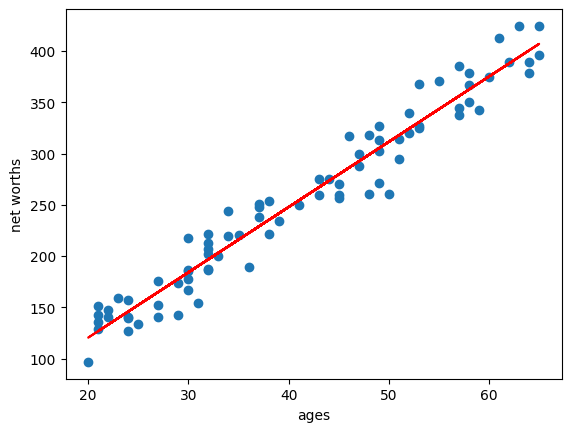

In [13]:
### only run this code if cleaned_data is returning data
if len(cleaned_data) > 0:
    ages, net_worths, errors = zip(*cleaned_data)
    ages       = numpy.reshape( numpy.array(ages), (len(ages), 1))
    net_worths = numpy.reshape( numpy.array(net_worths), (len(net_worths), 1))

    ### refit your cleaned data!
    try:
        reg.fit(ages, net_worths)
        plt.plot(ages, reg.predict(ages), color="red")
    except NameError:
        print("You don't seem to have regression imported/created,")
        print("   or else your regression object isn't named reg")
        print("   either way, only draw the scatter plot of the cleaned data")
    plt.scatter(ages, net_worths)
    plt.xlabel("ages")
    plt.ylabel("net worths")
    plt.show()


else:
    print("outlierCleaner() is returning an empty list, no refitting to be done")

In [14]:
print("slope after cleaning: ", reg.coef_)

slope after cleaning:  [[6.36859481]]


**What’s the new score when you use the regression to make predictions on the test set?**

In [15]:
print("score after cleaning: ", reg.score(ages_test, net_worths_test))

score after cleaning:  0.983189455395532
